# Q3: The zonal profile spread

**Concept.** `shape_spread` is the Belgian hourly day-ahead price minus the
hourly mean of SMARD's neighbouring-zone quarter-hourly series. Two facts shape
the whole section: it is a cross-zonal quantity, and the quarter-hourly leg
carries real intra-hour variation only from October 2025 onward (the SDAC
15-minute go-live); before that it replicates the hourly value four times.

**Hypotheses.**
1. The hour-of-day profile is non-flat: positive at the ramps, negative at the
   solar peak. A duck-curve difference between coupled zones with different
   solar shares.
2. The spread's dispersion grows with the intra-hour sigma of the
   quarter-hourly prices and with the German forecast-error regime.

**Method.** Hour-of-day decomposition; regression of the spread on intra-hour
sigma with hour fixed effects and Newey-West errors (24 lags);
regime-conditional sigma keyed on the forecast-error regime.


In [1]:
# Common imports, shared by all three notebooks.
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
FIG = RESULTS / 'figures'
TAB = RESULTS / 'tables'

with open(RESULTS / 'summary.json') as f:
    SUMMARY = json.load(f)

WINDOW = SUMMARY['window']
print(f"Sample window: {WINDOW['start']} → {WINDOW['end']}")


Sample window: 2018-10-01 → 2026-05-04


## 1.  Distribution and time series

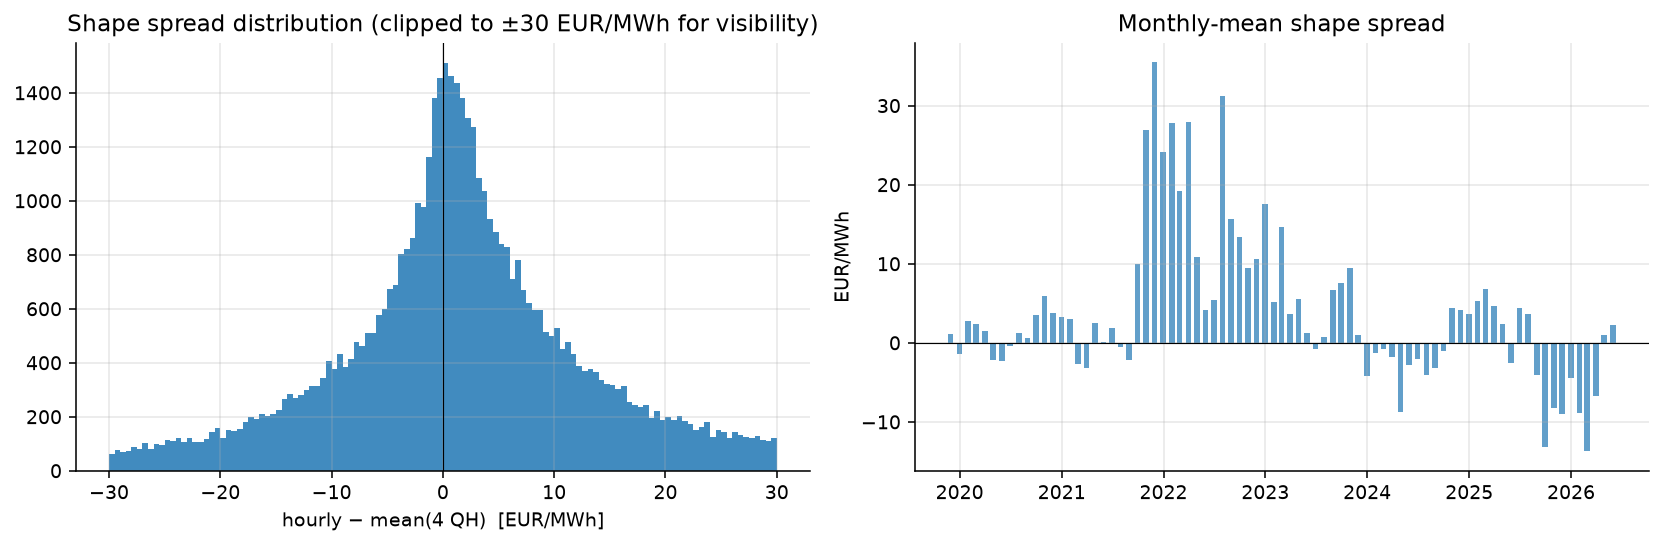

In [2]:
display(Image(str(FIG / 'q3_shape_dist_and_monthly.png')))

In [3]:
df = pd.read_csv(TAB / 'q3_shape_descriptives.csv', index_col=0)
display(df)

,shape_spread
count,56570.000000
mean,3.913672
std,22.619285
min,-322.170000
25%,-4.520000
50%,1.700000
75%,10.140000
max,248.730000


## 2.  Hour-of-day fingerprint (the headline)

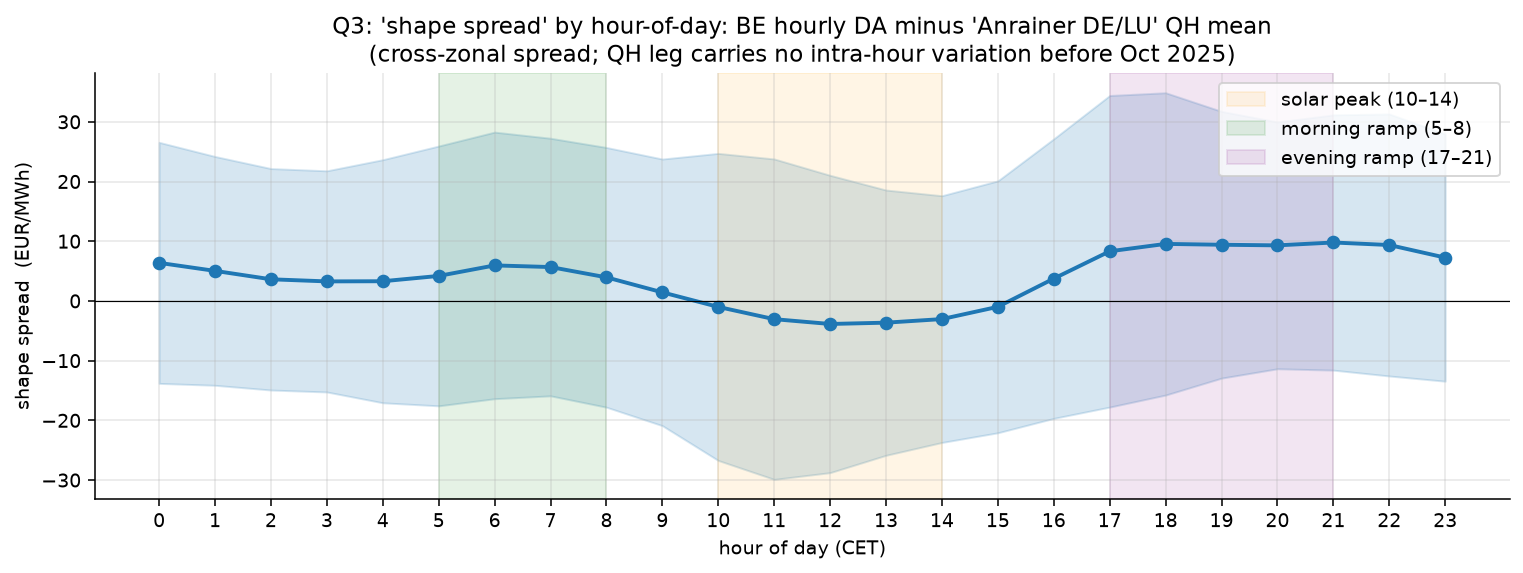

In [4]:
display(Image(str(FIG / 'q3_shape_by_hour.png')))

In [5]:
df = pd.read_csv(TAB / 'q3_shape_by_hour_full.csv', index_col=0)
display(df)

,mean,std,count,median
hour,,,,
0,6.375531,20.185875,2358,2.785
1,5.030949,19.162479,2357,2.150
2,3.623594,18.546487,2357,1.430
3,3.270471,18.520810,2357,1.080
4,3.297300,20.356222,2357,1.070
5,4.185863,21.756821,2357,1.710
6,5.949096,22.325030,2357,3.020
7,5.673928,21.570482,2357,2.520
8,3.949136,21.750374,2357,1.420


**Reading.** The profile switches sign twice a day. Positive at the ramps:
Belgium clears rich against the neighbour average as solar rolls off. Negative
at the solar peak: it clears cheap while PV floods the middle of the day.
Different solar shares and flexibility across coupled zones, showing up as a
stable hourly fingerprint.


## 3.  Regression: shape ~ const + σ(intra-hour) + hour FE

In [6]:
df = pd.read_csv(TAB / 'q3_regression_params.csv', index_col=0)
display(df.head(10))

,param,tstat,pvalue
0,6.597099,15.521058,2.498974e-54
1,-0.905954,-9.749414,1.855353e-22
2,-1.411598,-7.476921,7.608403e-14
3,-2.839523,-11.741542,7.804991e-32
4,-3.076383,-11.613165,3.532923e-31
5,-2.759393,-9.139774,6.258289e-20
6,-1.589662,-4.110438,3.949090e-05
7,0.313674,0.739883,4.593710e-01
8,0.033506,0.073719,9.412341e-01
9,-1.752532,-3.622319,2.919735e-04


In [7]:
r = SUMMARY['q3_regression']
display(Markdown(
f"""
With hour fixed effects absorbed, the *within-hour* coefficient on intra-hour σ
is **{r['sigma_coef']:+.3f}** (t = {r['sigma_t']:+.2f}), R² = **{r['r2']:.3f}**, n = {r['n_obs']:,}.

The sign should be negative if the hypothesis holds (more realised intra-hour
volatility → richer QH bundle → smaller / more-negative shape spread).
"""
))


With hour fixed effects absorbed, the *within-hour* coefficient on intra-hour σ
is **-0.906** (t = -9.75), R² = **0.054**, n = 56,569.

The sign should be negative if the hypothesis holds (more realised intra-hour
volatility → richer QH bundle → smaller / more-negative shape spread).


## 4.  Regime-conditional shape variance

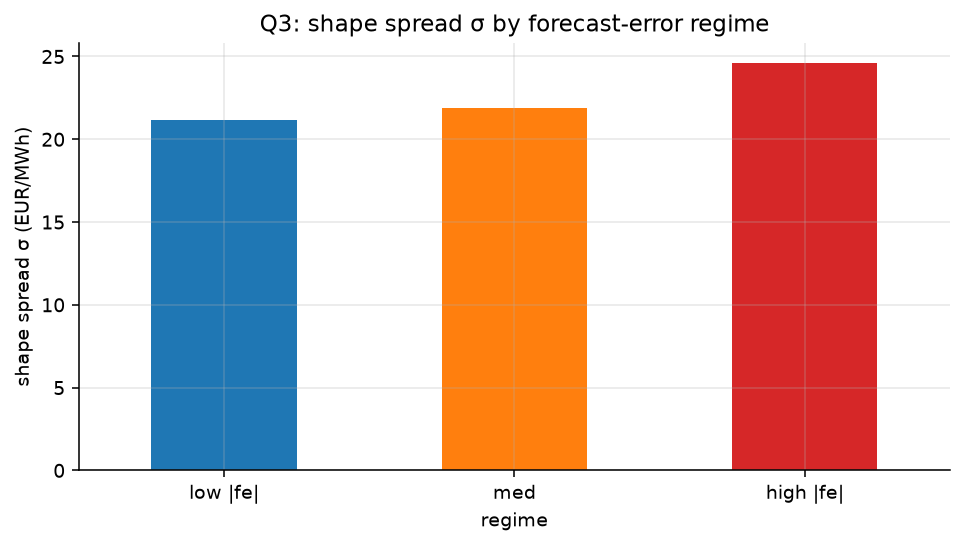

In [8]:
display(Image(str(FIG / 'q3_regime_variance.png')))

In [9]:
df = pd.read_csv(TAB / 'q3_shape_regime_variance.csv', index_col=0)
display(df)

,var,std,mean,count
regime,,,,
0,446.806733,21.137803,4.944208,18877
1,478.418467,21.872779,4.779503,18768
2,604.018319,24.576784,2.027288,18922


## 5.  Conclusions for Q3

In [10]:
hr = SUMMARY['q3_shape_by_hour_means']
hr_max = max(hr.items(), key=lambda kv: kv[1])
hr_min = min(hr.items(), key=lambda kv: kv[1])
r = SUMMARY['q3_regression']
rv = SUMMARY['q3_regime_variance']
stds = rv.get('std', {})
ratio = None
if len(stds) >= 3:
    ks = sorted(stds.keys(), key=lambda k: float(k))
    ratio = float(stds[ks[-1]]) / float(stds[ks[0]])
display(Markdown(
f"""
**Q3, in short.**

1. **Hour-of-day fingerprint.** Peak positive at hour **{hr_max[0]}**
   ({hr_max[1]:+.1f} EUR/MWh), peak negative at hour **{hr_min[0]}**
   ({hr_min[1]:+.1f} EUR/MWh). A {hr_max[1] - hr_min[1]:.1f} EUR/MWh
   peak-to-trough swing on the mean, with sigma much larger.

2. **Intra-hour dispersion prices the spread.** With hour fixed effects, the
   sigma coefficient is **{r['sigma_coef']:+.3f}** (t = {r['sigma_t']:+.2f},
   Newey-West), R2 = **{r['r2']:.3f}**. Identified on the post-Oct-2025 hours
   only, since sigma is zero by construction before the 15-minute go-live.

3. **Regime-conditional sigma ratio (high vs low forecast error):**
   {f'**{ratio:.1f}x**' if ratio else 'n/a'}. The spread widens with German
   renewable surprises, which after the cross-zonal reading is congestion
   sensitivity.

Caveats: the quarter-hourly mean is equal-weighted, not volume-weighted, and
negative prices stay in the sample; they are a structural feature here, not
outliers.
"""
))



**Q3, in short.**

1. **Hour-of-day fingerprint.** Peak positive at hour **21**
   (+9.8 EUR/MWh), peak negative at hour **12**
   (-3.9 EUR/MWh). A 13.6 EUR/MWh
   peak-to-trough swing on the mean, with sigma much larger.

2. **Intra-hour dispersion prices the spread.** With hour fixed effects, the
   sigma coefficient is **-0.906** (t = -9.75,
   Newey-West), R2 = **0.054**. Identified on the post-Oct-2025 hours
   only, since sigma is zero by construction before the 15-minute go-live.

3. **Regime-conditional sigma ratio (high vs low forecast error):**
   **1.2x**. The spread widens with German
   renewable surprises, which after the cross-zonal reading is congestion
   sensitivity.

Caveats: the quarter-hourly mean is equal-weighted, not volume-weighted, and
negative prices stay in the sample; they are a structural feature here, not
outliers.
